In [3]:
# 01 - Data Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
plt.rcParams['figure.dpi'] = 100


In [4]:
# Load raw data 
candidate_paths = [
    "data/raw/AI_Tool_Usage_and_Adoption_Survey__Responses_.xlsx",
    "AI_Tool_Usage_and_Adoption_Survey__Responses_.xlsx",
]
RAW_DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if RAW_DATA_PATH is None:
    raise FileNotFoundError("Raw survey file not found. Check `candidate_paths` above.")

print(f"Loading: {RAW_DATA_PATH}")
df = pd.read_excel(RAW_DATA_PATH)
df.head(3)


Loading: data/raw/AI_Tool_Usage_and_Adoption_Survey__Responses_.xlsx


,Timestamp,Email Address,Enter your age group.,What is your gender?,What is your current occupation?,Where do you primarily live?,Enter your Home Address.,"Do you currently use any AI tools (e.g., ChatGPT, Claude, Gemini, Copilot)?",Which AI tools do you use or are familiar with? (Select all that apply),Select how often you use AI tools.,What do you mainly use AI tools for?,What is the main purpose of using AI tools?,Which AI tool do you use most frequently?,Rate your satisfaction with your most-used AI tool.,Why do you prefer your most-used AI tool over others? (Select one),What are your main concerns about using AI tools?,Select the biggest reason you would switch to a different AI tool.,Select the main reason you do not use AI tools.,Would you consider using an AI tool in the future?,Enter any additional comments or suggestions regarding AI tools.
0,2026-09-15 15:42:29.032,smritigiri92@gmail.com,18 - 24,Female,Student,Semi - Urban,Lekhnath,Yes,"ChatGPT, Claude, Gemini",Several times a day,Study / Academic work,"Rapid completion of tasks, Learning and unders...",Claude,Satisfied,Better performance for my specific purpose,"Data privacy and security, Accuracy and reliab...",No Plan to Switch,NaN,NaN,IAM fine using AI tool
1,2026-09-15 15:48:37.254,NaN,18 - 24,Female,Student,Urban,Pokhara,Yes,"ChatGPT, Claude, Gemini",Several times a day,"Study / Academic work, Coding / Technical work...","Rapid completion of tasks, Learning and unders...",ChatGPT,Satisfied,Ease of use,"Data privacy and security, Accuracy and reliab...",Better Accuracy,NaN,NaN,Satisfied with currently using AI Tools.
2,2026-09-15 16:15:37.488,NaN,18 - 24,Male,Student,Urban,birauta,Yes,"ChatGPT, Claude, Gemini, Copilot, DeepSeek",Several times a day,"Study / Academic work, Content creation / Writ...","Rapid completion of tasks, Learning and unders...",Claude,Very Satisfied,Better performance for my specific purpose,Cost of premium features,Lower Cost,NaN,NaN,No


In [5]:
# Check shape 
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 200
Columns: 20


In [6]:
# Check columns 
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


 1. Timestamp
 2. Email Address
 3. Enter your age group.
 4. What is your gender?
 5. What is your current occupation?
 6. Where do you primarily live?
 7. Enter your Home Address.
 8. Do you currently use any AI tools (e.g., ChatGPT, Claude, Gemini, Copilot)?
 9. Which AI tools do you use or are familiar with? (Select all that apply)
10. Select how often you use AI tools.
11. What do you mainly use AI tools for?
12. What is the main purpose of using AI tools?
13. Which AI tool do you use most frequently?
14. Rate your satisfaction with your most-used AI tool.
15. Why do you prefer your most-used AI tool over others? (Select one)
16. What are your main concerns about using AI tools?
17.  Select the biggest reason you would switch to a different AI tool.
18. Select the main reason you do not use AI tools.
19. Would you consider using an AI tool in the future?
20. Enter any additional comments or suggestions regarding AI tools.


In [7]:
# Check data types 
df.dtypes


Timestamp                                                                      datetime64[us]
Email Address                                                                             str
Enter your age group.                                                                     str
What is your gender?                                                                      str
What is your current occupation?                                                          str
Where do you primarily live?                                                              str
Enter your Home Address.                                                                  str
Do you currently use any AI tools (e.g., ChatGPT, Claude, Gemini, Copilot)?               str
Which AI tools do you use or are familiar with? (Select all that apply)                   str
Select how often you use AI tools.                                                        str
What do you mainly use AI tools for?                        

In [8]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
missing_table


,Missing_Count,Missing_%
Email Address,199,99.5
Select the main reason you do not use AI tools.,195,97.5
Would you consider using an AI tool in the future?,195,97.5
Enter any additional comments or suggestions regarding AI tools.,10,5.0
What are your main concerns about using AI tools?,5,2.5
Why do you prefer your most-used AI tool over others? (Select one),5,2.5
Rate your satisfaction with your most-used AI tool.,5,2.5
What is the main purpose of using AI tools?,5,2.5
Which AI tool do you use most frequently?,5,2.5
What do you mainly use AI tools for?,5,2.5


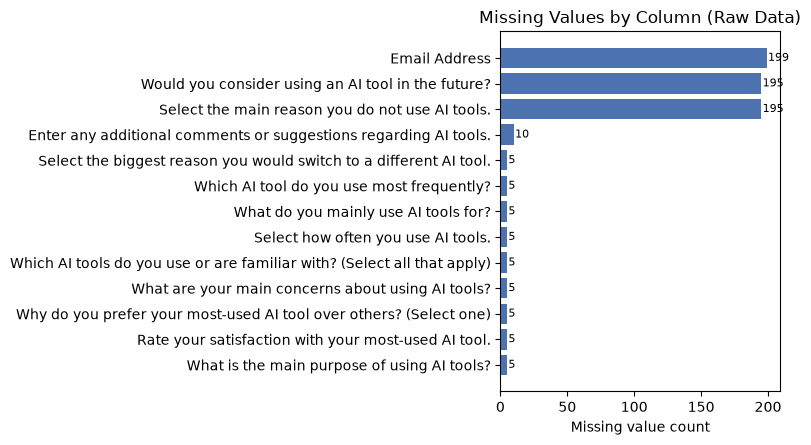

In [9]:
# Diagram: missing values per column (only columns with at least 1 missing value) 
nonzero = missing_table[missing_table['Missing_Count'] > 0].sort_values('Missing_Count')

fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(nonzero))))
ax.barh(nonzero.index, nonzero['Missing_Count'], color='#4C72B0')
ax.set_xlabel('Missing value count')
ax.set_title('Missing Values by Column (Raw Data)')
for i, v in enumerate(nonzero['Missing_Count']):
    ax.text(v + 1, i, str(int(v)), va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [10]:
# Check duplicates
print(f"Fully duplicated rows: {df.duplicated().sum()}")


Fully duplicated rows: 0


In [11]:
# Check unique categories (key columns) 
key_cols = [
    'Enter your age group.',
    'What is your gender?',
    'What is your current occupation?',
    'Where do you primarily live?',
    'Do you currently use any AI tools (e.g., ChatGPT, Claude, Gemini, Copilot)?',
    'Select how often you use AI tools.',
    'Which AI tool do you use most frequently?',
    'Rate your satisfaction with your most-used AI tool.',
]
for col in key_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- Enter your age group. ---
Enter your age group.
18 - 24         139
25 - 34          27
13 - 17          26
35 - 44           6
45 and above      2
Name: count, dtype: int64

--- What is your gender? ---
What is your gender?
Male      123
Female     77
Name: count, dtype: int64

--- What is your current occupation? ---
What is your current occupation?
Student                              135
IT professional                       24
Private-sector Employee               12
Teacher                               10
Business owner                         4
Government Employee                    4
Researcher                             2
Berojgar                               1
Ophthalmic assistant                   1
Engineering                            1
Unemployed                             1
Student plus working professional      1
dental surgen                          1
Freelancer                             1
Doctor                                 1
Social work                

In [12]:
# Observations to carry into cleaning (02_Data_Cleaning.ipynb) 
#  Email Address is almost entirely blank -> drop (PII, no info).
#  Enter your Home Address. is free text -> drop (PII, redundant with
#  Where do you primarily live?).
#   Respondents who answer "No" to using AI tools correctly have blank
#   AI-usage-specific answers -- this is survey skip-logic, not missing data
#   to fix.
#  Occupation free text has inconsistent spelling/casing.
#  One multi-select checkbox option ("Creating images, videos, or other
#   media") contains its own commas, which will corrupt naive comma-splitting
#   unless handled carefully in cleaning.
#  Comments column has null-equivalent filler ("no", "n/a", ".") and at
#  least one phone number typed in by mistake.
print(" 02_Data_Cleaning.ipynb needs to address.")


 02_Data_Cleaning.ipynb needs to address.
